In [1]:
import cv2
import numpy as np
import json
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime, timedelta
import backend.processing_logic as processing_logic

# --- Simulated Frame Sequence ---
# Prepare a sequence of image frames for processing.
image_paths = [
    'capture1.jpg',
    'capture2.jpg', 
    'capture3.jpg'
]
yolo_model_path = 'backend/resource/models/yolov8n-seg.pt'
ollama_api_url = 'http://localhost:11434/api/generate' 
deepseek_model_name = 'deepseek-r1:8b'

# Simulate capture times for each image
base_time = datetime.now()
capture_times = [(base_time + timedelta(seconds=i)).strftime("%Y-%m-%d %H:%M:%S") for i in range(len(image_paths))]

# Load the YOLO model
yolo_model = YOLO(yolo_model_path)

# Load the secondary model for object classification
# Assuming the secondary model is a MobileNetV3 small model for classification
secondary_model = processing_logic.load_secondary_model('mobilenet_v3_small', num_classes=4)



/home/joe-ubuntu/anaconda3/envs/image2text/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/joe-ubuntu/anaconda3/envs/image2text/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Processing frame sequence with optical flow...
  - Processing frame 1...

0: 480x640 1 person, 61.5ms
Speed: 4.9ms preprocess, 61.5ms inference, 347.9ms postprocess per image at shape (1, 3, 480, 640)
  - Processing frame 2...

0: 480x640 1 person, 1 cup, 1 tv, 5.8ms
Speed: 1.1ms preprocess, 5.8ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
  - Processing frame 3...

0: 480x640 1 person, 1 cup, 1 tv, 6.0ms
Speed: 1.0ms preprocess, 6.0ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)
Sequence processing complete.
\n--- Aggregated JSON for LLM (with motion info) ---
{
  "summary": "This is a sequence of image frames. Analyze the objects and their changes over time.",
  "frames": [
    {
      "frame_id": 1,
      "capture_time": "2025-07-30 10:16:00",
      "detections": [
        {
          "class": "person",
          "group": "person",
          "confidence": 0.9126547574996948,
          "bbox": [
            440,
            103,
            6

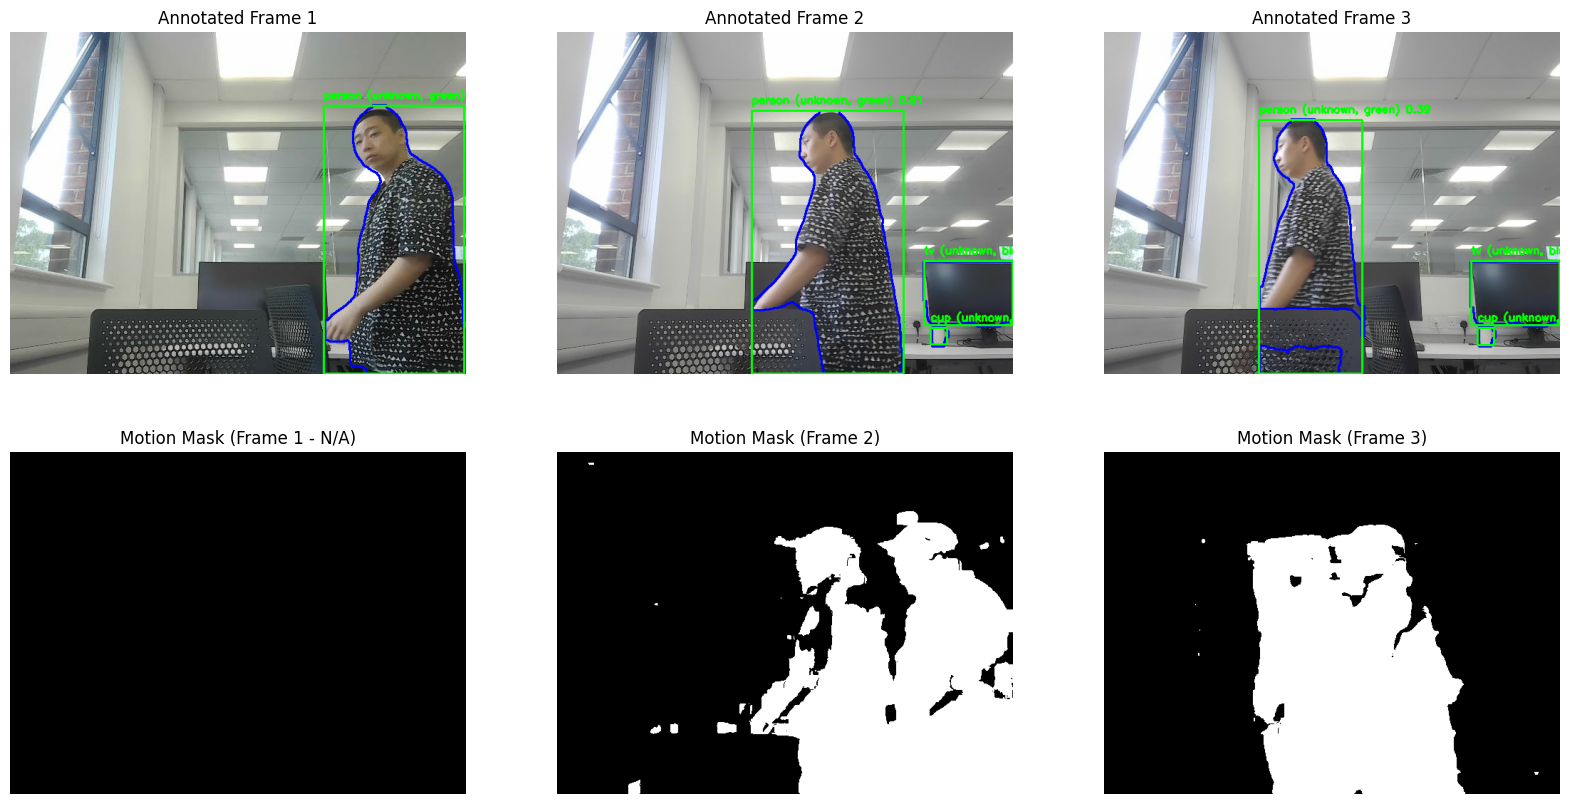

In [2]:
# --- Loop through each frame ---
all_detections = []
annotated_images = []
motion_masks = []
prev_gray = None

print("Processing frame sequence with optical flow...")
for i, path in enumerate(image_paths):
    print(f"  - Processing frame {i+1}...")
    image_bgr = cv2.imread(path)
    current_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    
    motion_mask = None
    # Calculate motion mask if there is a previous frame
    if prev_gray is not None:
        motion_mask = processing_logic.detect_motion_with_optical_flow(prev_gray, current_gray)
        motion_masks.append(motion_mask)

    # Call the modified object detection function with the motion mask
    detections_list, annotated_image = processing_logic.detect_objects_yolo(
        image_bgr, yolo_model, secondary_model=secondary_model, color_space='HSV', motion_mask=motion_mask
    )
    
    all_detections.append(detections_list)
    annotated_images.append(annotated_image)
    
    # Update previous frame
    prev_gray = current_gray.copy()

print("Sequence processing complete.")

# --- Format the detections for LLM ---
json_sequence_detections = processing_logic.format_sequence_detections_for_llm(
    all_detections, capture_times
)

# Print the aggregated JSON for LLM
print("\\n--- Aggregated JSON for LLM (with motion info) ---")
print(json_sequence_detections)

# --- Visualize the results ---
fig, axes = plt.subplots(2, len(annotated_images), figsize=(20, 10))
for i, img in enumerate(annotated_images):
    axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'Annotated Frame {i+1}')
    axes[0, i].axis('off')

# Show motion masks (the first frame has no motion mask)
axes[1, 0].imshow(np.zeros_like(annotated_images[0]), cmap='gray')
axes[1, 0].set_title('Motion Mask (Frame 1 - N/A)')
axes[1, 0].axis('off')
for i, mask in enumerate(motion_masks):
    axes[1, i+1].imshow(mask, cmap='gray')
    axes[1, i+1].set_title(f'Motion Mask (Frame {i+2})')
    axes[1, i+1].axis('off')

plt.show()

In [3]:
import sys
# Ask a question about the image sequence
# print("Enter your question about the image sequence (or 'quit' to exit):")
# question = "what did you see?"

while True:
    question = input("Enter your question about the image (or 'quit' to exit): ").strip()
    if question.lower() == 'quit':
        break
    if not question:
        print("Please enter a valid question.")
        sys.stdout.flush()
        continue

    print(f"Question: {question}")
    print("Generating answer, please wait...")

    # Use the aggregated JSON data to ask the question
    final_answer, complete_response, metrics = processing_logic.answer_question_with_deepseek(
        json_sequence_detections,
        question,
        ollama_api_url,
        deepseek_model_name
    )
    
    print("------------Answer generation complete------------")
    print(f"Answer: {final_answer}")
    print("--------------------")
    print(f"Metrics: {metrics}")
    print("--------------------")
    print("Complete Response:")
    print(complete_response)
    print("--------------------")
    # break

Question: what did you see
Generating answer, please wait...
------------Answer generation complete------------
Answer: In each frame from ID 1 to ID 3, you saw one or more objects: a green person sitting still in the first frame; then, in the second frame (next second), that same person is moving but appears smaller on screen, while also seeing a blue TV and a yellow cup for the first time. The third frame shows the same green person now moving again, the blue TV has stopped moving, and the previously detected yellow cup no longer appears.
--------------------
Metrics: {'question': 'what did you see', 'start_time': 1753866982.671291, 'inference_time': 105.36615109443665, 'memory_mb': 1616.60546875, 'retry_attempts': 0, 'status': 'success'}
--------------------
Complete Response:
<think>
Hmm, the user is asking me to analyze a sequence of image frames and provide a concise summary of what I observed. They've provided structured data with three frames showing different objects.

Looking